# Project Title and Problem Statement
## Project title:
***Cell Morphology and Measurement Analysis Using Python (pandas and matplotlib)***
## Problem statement:
 Analyze measurements extracted from microscopic cell images to identify differences
in cell size, shape, intensity, and morphology and detect potentially abnormal cells.
Recommended approach: first analyze cell measurements in CSV form. After that works well, extend the
project to actual microscope images.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cell_measurements.csv to cell_measurements (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("cell_measurements.csv")

df.head()

,cell_id,cell_type,area,perimeter,intensity
0,1,Type_A,293.71,64.36,121.77
1,2,Type_A,233.20,71.85,128.54
2,3,Type_A,313.77,62.63,139.77
3,4,Type_A,322.33,66.51,117.91
4,5,Type_A,192.20,47.65,134.38


In [ ]:
df

,cell_id,cell_type,area,perimeter,intensity
0,1,Type_A,293.71,64.36,121.77
1,2,Type_A,233.20,71.85,128.54
2,3,Type_A,313.77,62.63,139.77
3,4,Type_A,322.33,66.51,117.91
4,5,Type_A,192.20,47.65,134.38
...,...,...,...,...,...
196,197,Type_B,471.82,88.84,163.55
197,198,Type_B,404.35,84.06,192.88
198,199,Type_B,429.67,86.77,180.32
199,200,Type_B,419.38,75.66,135.95


In [ ]:
df.shape

(201, 5)

In [ ]:
df.columns

Index(['cell_id', 'cell_type', 'area', 'perimeter', 'intensity'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cell_id    201 non-null    int64  
 1   cell_type  201 non-null    object 
 2   area       200 non-null    float64
 3   perimeter  200 non-null    float64
 4   intensity  200 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 8.0+ KB


In [ ]:
df.describe() # to see the first problem. (-ve area and perimeter which are not possible biologically)

,cell_id,area,perimeter,intensity
count,201.000000,200.000000,200.000000,200.000000
mean,100.253731,357.747000,71.776550,150.137050
std,57.839781,125.561548,14.658434,40.218344
min,1.000000,-50.000000,-10.000000,82.990000
25%,51.000000,280.230000,61.172500,122.640000
50%,100.000000,334.705000,70.590000,144.760000
75%,150.000000,423.342500,84.102500,173.087500
max,200.000000,1500.000000,102.950000,500.000000


solving the problem of -ve area and perimeter

In [ ]:
df[df["area"] < 0] # area is wrong

,cell_id,cell_type,area,perimeter,intensity
88,89,Type_A,-50.0,59.95,109.67


In [ ]:
df[df["perimeter"] < 0] # perimeter is wrong

,cell_id,cell_type,area,perimeter,intensity
142,143,Type_B,291.42,-10.0,180.45


In [ ]:
df[df["cell_type"] == "Type_A"]["area"].describe()

,area
count,100.000000
mean,286.184900
std,131.496314
min,-50.000000
25%,250.990000
50%,279.900000
75%,304.072500
max,1500.000000


In [ ]:
df[df["cell_type"] == "Type_B"]["perimeter"].describe()

,perimeter
count,100.000000
mean,81.996400
std,13.017672
min,-10.000000
25%,75.900000
50%,84.105000
75%,89.352500
max,102.950000


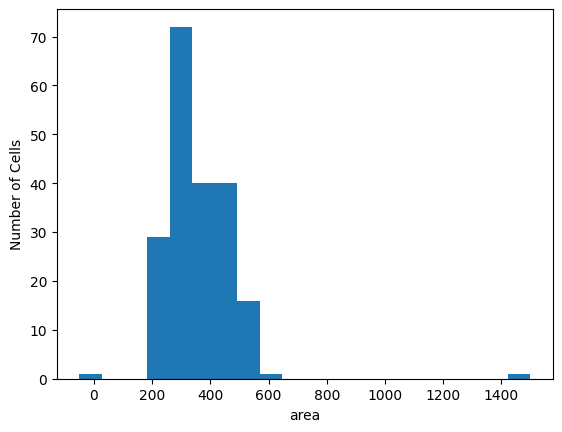

In [ ]:
plt.hist(df["area"], bins=20)
plt.xlabel("area")
plt.ylabel("Number of Cells")
plt.show()
# shows the max outlier, thats why we dont take mean but median cuz mean is afected by that >1400 outlier max value

In [ ]:
median_area = df.loc[
    (df["cell_type"] == "Type_A") & (df["area"] >= 0),
    "area"
].median()

print(median_area)

280.56


In [ ]:
df.loc[df["cell_id"] == 89, "area"] = median_area

In [ ]:
df[df["cell_id"] == 89]

,cell_id,cell_type,area,perimeter,intensity
88,89,Type_A,280.56,59.95,109.67


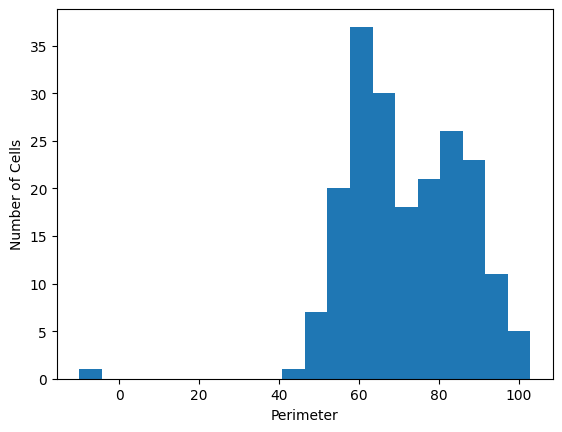

In [ ]:
plt.hist(df["perimeter"], bins=20)
plt.xlabel("Perimeter")
plt.ylabel("Number of Cells")
plt.show()

In [ ]:
mean_perimeter = df.loc[df["perimeter"] >= 0, "perimeter"].mean()
# we are checking mean here and not median cuz there is no big outlier here like the max in area.
print(mean_perimeter)

72.18748743718594


In [ ]:
df.loc[df["cell_id"] == 143, "perimeter"] = mean_perimeter

In [ ]:
df[df["cell_id"] == 143]

,cell_id,cell_type,area,perimeter,intensity
142,143,Type_B,291.42,72.187487,180.45


check for missing values

In [ ]:
df.isna().sum()

,0
cell_id,0
cell_type,0
area,1
perimeter,1
intensity,1


In [ ]:
df[df.isna().any(axis=1)]

,cell_id,cell_type,area,perimeter,intensity
7,8,Type_A,NaN,53.47,139.93
24,25,Type_A,260.73,62.63,NaN
61,62,Type_A,264.93,NaN,110.00


In [ ]:
median_area = df.loc[
    (df["cell_type"] == "Type_A") & (df["area"] >= 0),
    "area"
].median()

median_perimeter = df.loc[
    (df["cell_type"] == "Type_A") & (df["perimeter"] >= 0),
    "perimeter"
].median()

median_intensity = df.loc[
    (df["cell_type"] == "Type_A") & (df["intensity"] >= 0),
    "intensity"
].median()

In [ ]:
df.loc[df["cell_id"] == 8, "area"] = median_area
df.loc[df["cell_id"] == 25, "intensity"] = median_intensity
df.loc[df["cell_id"] == 62, "perimeter"] = median_perimeter

In [ ]:
df.isna().sum()

,0
cell_id,0
cell_type,0
area,0
perimeter,0
intensity,0


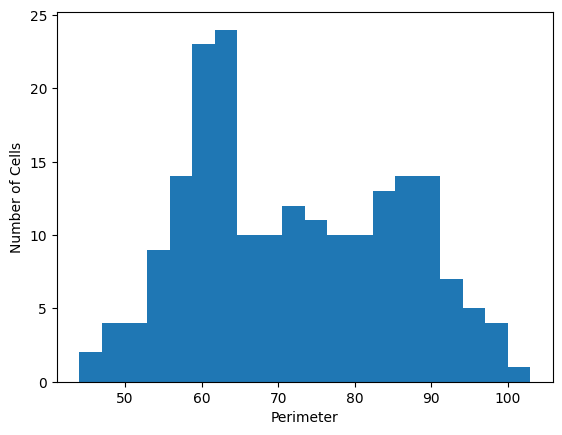

In [ ]:
plt.hist(df["perimeter"], bins=20)
plt.xlabel("Perimeter")
plt.ylabel("Number of Cells")
plt.show() # there are no outliers in perimeter now

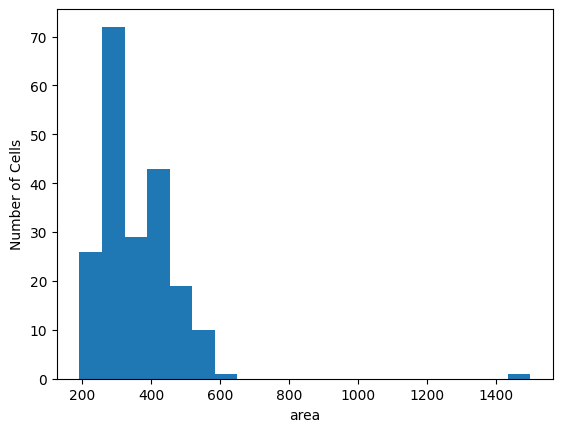

In [ ]:
plt.hist(df["area"], bins=20)
plt.xlabel("area")
plt.ylabel("Number of Cells")
plt.show() # one outlier which is too large in area.

In [ ]:
df.describe()

,cell_id,area,perimeter,intensity
count,201.000000,201.000000,201.000000,201.000000
mean,100.253731,359.007562,72.133321,150.006368
std,57.839781,122.121117,13.445447,40.160431
min,1.000000,192.200000,44.030000,82.990000
25%,51.000000,280.560000,61.280000,122.640000
50%,100.000000,334.400000,70.740000,144.610000
75%,150.000000,422.290000,84.100000,173.080000
max,200.000000,1500.000000,102.950000,500.000000


In [ ]:
df.loc[df["area"] > 1000]

,cell_id,cell_type,area,perimeter,intensity
35,36,Type_A,1500.0,57.42,114.11


In [ ]:
df.loc[df["area"] > 1000, ["cell_id", "cell_type", "area", "perimeter", "intensity"]]

,cell_id,cell_type,area,perimeter,intensity
35,36,Type_A,1500.0,57.42,114.11


In [ ]:

df["circularity"] = (4 * np.pi * df["area"]) / (df["perimeter"] ** 2)

In [ ]:
df.head()

,cell_id,cell_type,area,perimeter,intensity,circularity
0,1,Type_A,293.71,64.36,121.77,0.891039
1,2,Type_A,233.20,71.85,128.54,0.567656
2,3,Type_A,313.77,62.63,139.77,1.005209
3,4,Type_A,322.33,66.51,117.91,0.915665
4,5,Type_A,192.20,47.65,134.38,1.063745


In [ ]:
df.describe()

,cell_id,area,perimeter,intensity,circularity
count,201.000000,201.000000,201.000000,201.000000,201.000000
mean,100.253731,359.007562,72.133321,150.006368,0.913183
std,57.839781,122.121117,13.445447,40.160431,0.431803
min,1.000000,192.200000,44.030000,82.990000,0.419222
25%,51.000000,280.560000,61.280000,122.640000,0.682698
50%,100.000000,334.400000,70.740000,144.610000,0.842094
75%,150.000000,422.290000,84.100000,173.080000,1.033195
max,200.000000,1500.000000,102.950000,500.000000,5.717086


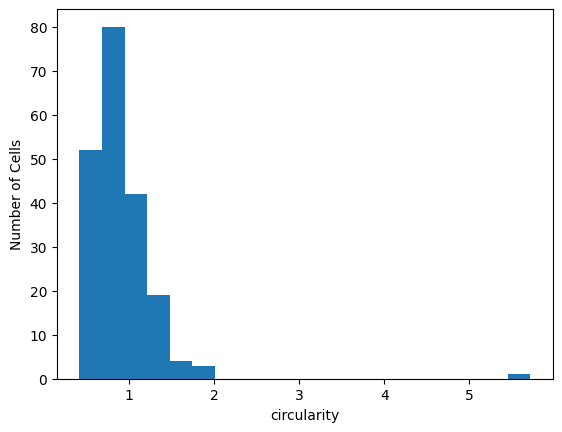

In [ ]:
plt.hist(df["circularity"], bins=20)
plt.xlabel("circularity")
plt.ylabel("Number of Cells")
plt.show() # the outlier is due to the area outlier.

In [ ]:
df.groupby("cell_type")[["area", "perimeter", "intensity", "circularity"]].mean()

,area,perimeter,intensity,circularity
cell_type,,,,
Type_A,289.402079,61.554158,124.323564,1.003476
Type_B,429.309100,82.818275,175.946000,0.821986


In [ ]:
df.groupby("cell_type")[["area", "perimeter", "intensity", "circularity"]].median()

,area,perimeter,intensity,circularity
cell_type,,,,
Type_A,280.56,61.300,123.870,0.915665
Type_B,421.57,84.105,173.095,0.754636


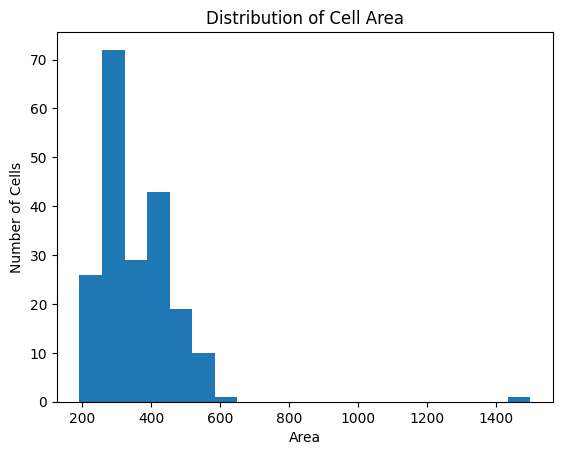

In [ ]:
plt.hist(df["area"], bins=20)
plt.xlabel("Area")
plt.ylabel("Number of Cells")
plt.title("Distribution of Cell Area")
plt.show()

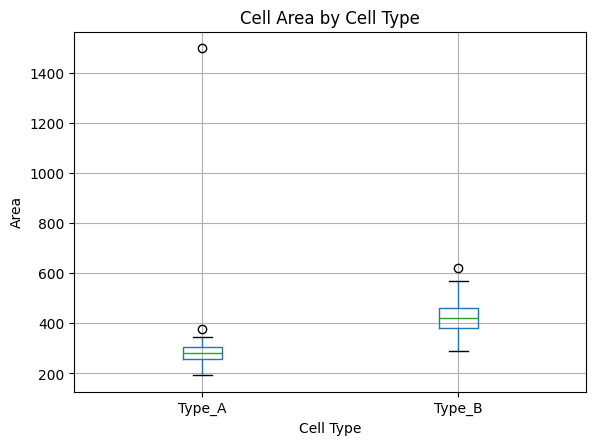

'Line inside the box = median area\nBox = middle 50% of the cells (25th to 75th percentile)\nWhiskers = the main range of the data\nCircles = potential outliers'

In [ ]:
df.boxplot(column="area", by="cell_type")
plt.title("Cell Area by Cell Type")
plt.suptitle("")
plt.xlabel("Cell Type")
plt.ylabel("Area")
plt.show()
'''Line inside the box = median area
Box = middle 50% of the cells (25th to 75th percentile)
Whiskers = the main range of the data
Circles = potential outliers'''

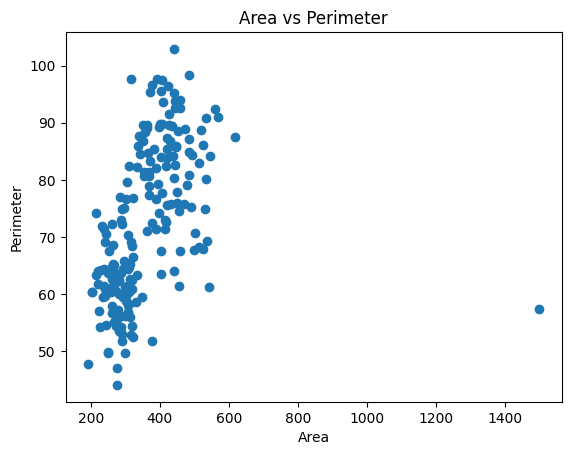

In [ ]:
plt.scatter(df["area"], df["perimeter"])
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.title("Area vs Perimeter")
plt.show()

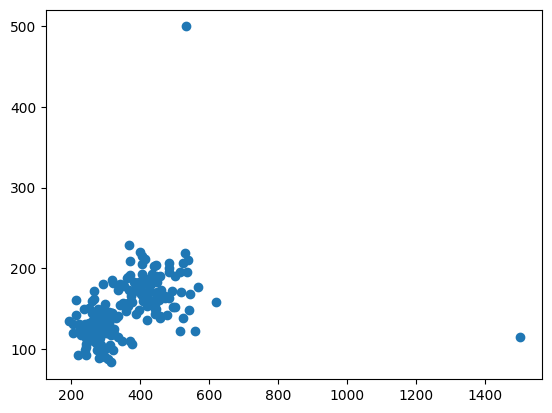

In [ ]:
plt.scatter(df["area"], df["intensity"])

In [ ]:
df.nlargest(10, "area")

,cell_id,cell_type,area,perimeter,intensity,circularity
35,36,Type_A,1500.00,57.42,114.11,5.717086
139,140,Type_B,619.40,87.48,157.70,1.017100
162,163,Type_B,568.35,91.00,176.13,0.862468
138,139,Type_B,559.79,92.40,122.33,0.823931
155,156,Type_B,544.92,84.10,168.24,0.968168
190,191,Type_B,542.04,61.21,148.11,1.818011
189,190,Type_B,537.31,69.29,210.44,1.406351
118,119,Type_B,534.12,90.91,194.75,0.812130
176,177,Type_B,532.64,80.15,500.00,1.041925
185,186,Type_B,529.82,74.85,218.94,1.188378


In [ ]:
df.nlargest(10, "perimeter")

,cell_id,cell_type,area,perimeter,intensity,circularity
175,176,Type_B,441.22,102.95,142.99,0.523133
124,125,Type_B,484.28,98.39,205.88,0.628644
112,113,Type_B,391.38,97.70,177.19,0.515252
109,110,Type_B,317.72,97.59,185.23,0.419222
100,101,Type_B,405.42,97.55,205.00,0.535378
144,145,Type_B,377.16,96.55,169.43,0.508430
178,179,Type_B,422.29,96.44,169.44,0.570566
130,131,Type_B,404.66,95.60,167.04,0.556396
165,166,Type_B,371.31,95.33,191.27,0.513437
149,150,Type_B,440.21,95.28,189.58,0.609349


In [ ]:
df.nlargest(10, "intensity")

,cell_id,cell_type,area,perimeter,intensity,circularity
176,177,Type_B,532.64,80.15,500.00,1.041925
106,107,Type_B,368.25,78.99,228.25,0.741666
153,154,Type_B,398.39,89.32,219.77,0.627510
185,186,Type_B,529.82,74.85,218.94,1.188378
192,193,Type_B,405.09,77.75,215.07,0.842094
119,120,Type_B,414.44,71.40,210.84,1.021586
189,190,Type_B,537.31,69.29,210.44,1.406351
129,130,Type_B,369.77,77.34,209.42,0.776843
126,127,Type_B,525.11,67.85,207.01,1.433377
124,125,Type_B,484.28,98.39,205.88,0.628644


In [ ]:
df[df["cell_id"] == 36]

,cell_id,cell_type,area,perimeter,intensity,circularity
35,36,Type_A,1500.0,57.42,114.11,5.717086


In [ ]:
df.loc[df["cell_id"] == 36, "area"] = median_area

In [ ]:
df["circularity"] = (4 * np.pi * df["area"]) / (df["perimeter"] ** 2)

In [ ]:
df[df["cell_id"] == 36]

,cell_id,cell_type,area,perimeter,intensity,circularity
35,36,Type_A,280.56,57.42,114.11,1.069324


In [ ]:
df[df["circularity"] > 1].count()

,0
cell_id,60
cell_type,60
area,60
perimeter,60
intensity,60
circularity,60


In [ ]:
(df["circularity"] > 1).sum() # since so many cells have circularity > 0  then that means the formula we applied is not applicable for this set of data, so instead of changing data lets remove circularity column.

np.int64(60)

In [ ]:
df.drop(columns=['circularity'],inplace=True)

In [ ]:
df.head()

,cell_id,cell_type,area,perimeter,intensity
0,1,Type_A,293.71,64.36,121.77
1,2,Type_A,233.20,71.85,128.54
2,3,Type_A,313.77,62.63,139.77
3,4,Type_A,322.33,66.51,117.91
4,5,Type_A,192.20,47.65,134.38


In [ ]:
df[df.duplicated("cell_id", keep=False)]

,cell_id,cell_type,area,perimeter,intensity
50,51,Type_A,293.01,59.42,122.64
200,51,Type_A,293.01,59.42,122.64


In [ ]:
df["cell_id"].nunique()

200

In [ ]:
df = df.drop_duplicates(subset="cell_id", keep="first")

In [ ]:
print(df.shape)
print(df["cell_id"].nunique())

(200, 5)
200


In [ ]:
df.duplicated("cell_id").sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
cell_id,0
cell_type,0
area,0
perimeter,0
intensity,0


In [ ]:
df.describe()

,cell_id,area,perimeter,intensity
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,353.240350,72.196887,150.143200
std,57.879185,91.771945,13.448874,40.214212
min,1.000000,192.200000,44.030000,82.990000
25%,50.750000,280.560000,61.295000,122.820000
50%,100.500000,332.565000,70.895000,144.760000
75%,150.250000,421.210000,84.102500,173.087500
max,200.000000,619.400000,102.950000,500.000000


data cleaning is finally done, now data analysing

In [ ]:
df.groupby("cell_type")[["area", "perimeter", "intensity"]].mean()

,area,perimeter,intensity
cell_type,,,
Type_A,277.1716,61.575500,124.3404
Type_B,429.3091,82.818275,175.9460


In [ ]:
df.groupby("cell_type")[["area", "perimeter", "intensity"]].median()

,area,perimeter,intensity
cell_type,,,
Type_A,280.56,61.310,123.925
Type_B,421.57,84.105,173.095


In [ ]:
df.groupby("cell_type")[["area", "perimeter", "intensity"]].std()

,area,perimeter,intensity
cell_type,,,
Type_A,34.435383,7.169626,17.826276
Type_B,63.668267,9.179384,39.848533


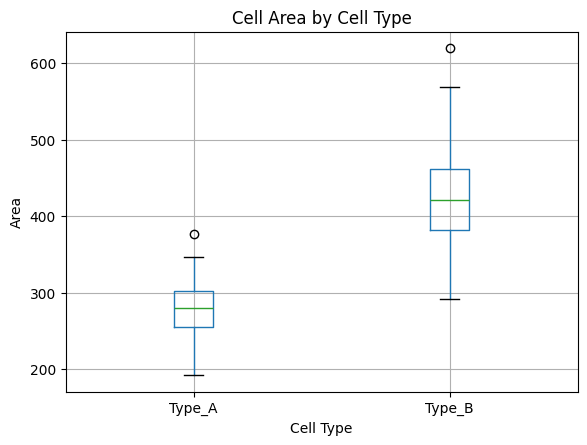

In [ ]:
df.boxplot(column="area", by="cell_type")
plt.title("Cell Area by Cell Type")
plt.suptitle("")
plt.xlabel("Cell Type")
plt.ylabel("Area")
plt.show()

Type_B cells are generally larger than Type_A cells in this dataset.

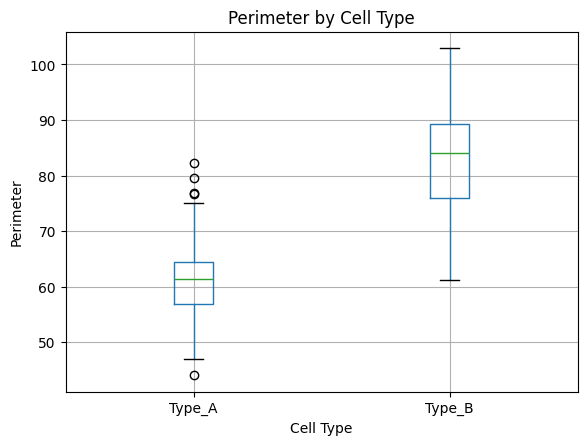

In [ ]:
df.boxplot(column="perimeter", by="cell_type")
plt.title("Perimeter by Cell Type")
plt.suptitle("")
plt.xlabel("Cell Type")
plt.ylabel("Perimeter")
plt.show()

Type_B cells generally have larger perimeters and somewhat greater variation.

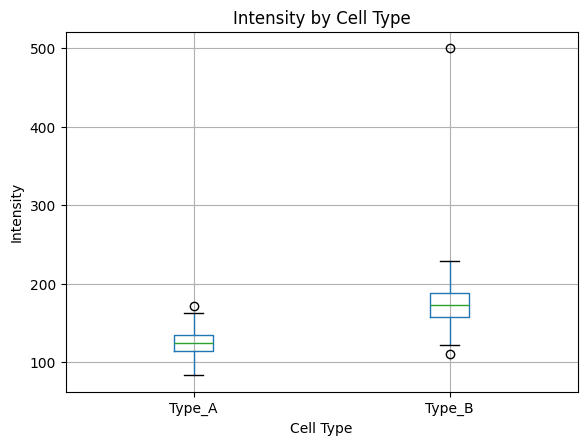

In [ ]:
df.boxplot(column="intensity", by="cell_type")
plt.title("Intensity by Cell Type")
plt.suptitle("")
plt.xlabel("Cell Type")
plt.ylabel("Intensity")
plt.show()

Type_B cells generally have higher intensity, with considerably more variation than Type_A.

| Feature         | Type_A  | Type_B |
| --------------- | ------- | ------ |
| **Area**        | Smaller | Larger |
| **Perimeter**   | Smaller | Larger |
| **Intensity**   | Lower   | Higher |
| **Variability** | Lower   | Higher |


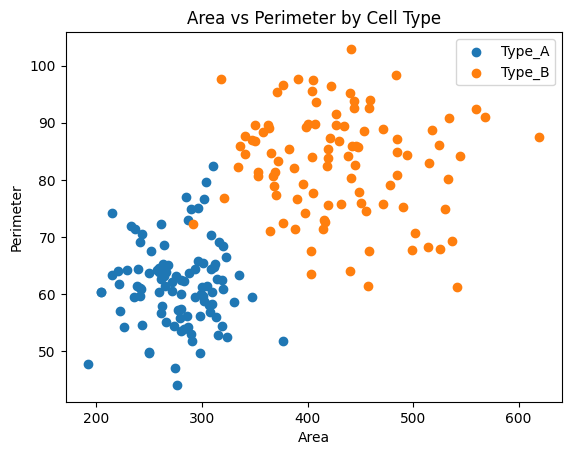

In [ ]:
plt.scatter(
    df[df["cell_type"] == "Type_A"]["area"],
    df[df["cell_type"] == "Type_A"]["perimeter"],
    label="Type_A"
)

plt.scatter(
    df[df["cell_type"] == "Type_B"]["area"],
    df[df["cell_type"] == "Type_B"]["perimeter"],
    label="Type_B"
)

plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.title("Area vs Perimeter by Cell Type")
plt.legend()
plt.show()

In [ ]:
df[["area", "perimeter"]].corr()

,area,perimeter
area,1.000000,0.634119
perimeter,0.634119,1.000000


In [ ]:
df.groupby("cell_type")[["area", "perimeter"]].corr()

area  perimeter
cell_type                               
Type_A    area       1.000000  -0.002517
          perimeter -0.002517   1.000000
Type_B    area       1.000000  -0.099945
          perimeter -0.099945   1.000000

Area and perimeter showed a moderate positive correlation when all cells were considered together (r = 0.634). However, correlations within Type_A (r = −0.003) and Type_B (r = −0.100) were close to zero, suggesting that the overall correlation was largely driven by differences between the two cell types rather than a strong within-type relationship.

In [ ]:
df[["area", "intensity"]].corr()

,area,intensity
area,1.000000,0.567033
intensity,0.567033,1.000000


In [ ]:
df.groupby("cell_type")[["area", "intensity"]].corr()

area  intensity
cell_type                               
Type_A    area       1.000000  -0.079595
          intensity -0.079595   1.000000
Type_B    area       1.000000   0.114336
          intensity  0.114336   1.000000

Area and intensity showed a moderate positive correlation overall (r = 0.567), but correlations within Type_A (r = −0.080) and Type_B (r = 0.114) were close to zero. This suggests that the overall correlation was primarily associated with differences between the two cell types rather than a strong relationship between area and intensity within either type.

In [ ]:
df[["perimeter", "intensity"]].corr()

,perimeter,intensity
perimeter,1.000000,0.504885
intensity,0.504885,1.000000


In [ ]:
df.groupby("cell_type")[["perimeter", "intensity"]].corr()

perimeter  intensity
cell_type                                
Type_A    perimeter   1.000000   0.148127
          intensity   0.148127   1.000000
Type_B    perimeter   1.000000  -0.064827
          intensity  -0.064827   1.000000

The correlations between morphology measurements and intensity observed across all cells appear to be driven largely by differences between Type_A and Type_B rather than strong relationships within individual cell types.

In [ ]:
df.sort_values("intensity", ascending=False).head(10)

,cell_id,cell_type,area,perimeter,intensity
176,177,Type_B,532.64,80.15,500.00
106,107,Type_B,368.25,78.99,228.25
153,154,Type_B,398.39,89.32,219.77
185,186,Type_B,529.82,74.85,218.94
192,193,Type_B,405.09,77.75,215.07
119,120,Type_B,414.44,71.40,210.84
189,190,Type_B,537.31,69.29,210.44
129,130,Type_B,369.77,77.34,209.42
126,127,Type_B,525.11,67.85,207.01
124,125,Type_B,484.28,98.39,205.88


Cell 177 has an unusually high intensity compared with the rest of the dataset and should be treated as a potential outlier for further investigation.

In [ ]:
df.sort_values("area", ascending=False).head(10)

,cell_id,cell_type,area,perimeter,intensity
139,140,Type_B,619.40,87.48,157.70
162,163,Type_B,568.35,91.00,176.13
138,139,Type_B,559.79,92.40,122.33
155,156,Type_B,544.92,84.10,168.24
190,191,Type_B,542.04,61.21,148.11
189,190,Type_B,537.31,69.29,210.44
118,119,Type_B,534.12,90.91,194.75
176,177,Type_B,532.64,80.15,500.00
185,186,Type_B,529.82,74.85,218.94
126,127,Type_B,525.11,67.85,207.01


area has no bizzare value

In [ ]:
df.sort_values("perimeter", ascending=False).head(10)

,cell_id,cell_type,area,perimeter,intensity
175,176,Type_B,441.22,102.95,142.99
124,125,Type_B,484.28,98.39,205.88
112,113,Type_B,391.38,97.70,177.19
109,110,Type_B,317.72,97.59,185.23
100,101,Type_B,405.42,97.55,205.00
144,145,Type_B,377.16,96.55,169.43
178,179,Type_B,422.29,96.44,169.44
130,131,Type_B,404.66,95.60,167.04
165,166,Type_B,371.31,95.33,191.27
149,150,Type_B,440.21,95.28,189.58


no outlier in perimeter also, so the only outlier is the intensity one

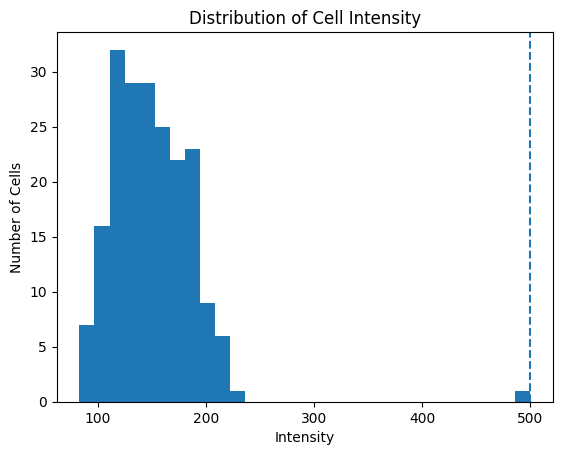

In [ ]:
plt.hist(df["intensity"], bins=30)
plt.axvline(500, linestyle="--")
plt.xlabel("Intensity")
plt.ylabel("Number of Cells")
plt.title("Distribution of Cell Intensity")
plt.show()

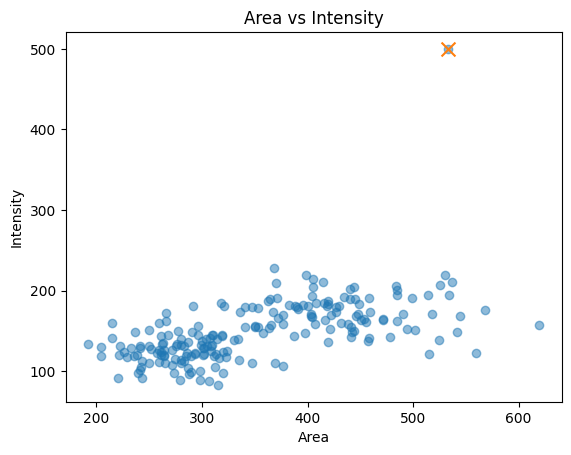

In [ ]:
plt.scatter(df["area"], df["intensity"], alpha=0.5)

cell_177 = df[df["cell_id"] == 177]

plt.scatter(
    cell_177["area"],
    cell_177["intensity"],
    s=100,
    marker="x"
)

plt.xlabel("Area")
plt.ylabel("Intensity")
plt.title("Area vs Intensity")
plt.show()

area is normal that is <600 but the intensity is too high way beyond the normal domain.

In [ ]:
df[df["intensity"] > 250] # i.e., only cell 177 has intensity that high there are no other outliers.

,cell_id,cell_type,area,perimeter,intensity
176,177,Type_B,532.64,80.15,500.0


Only the intensity is unusually high, but we cant remove it as we dont have enough evidence whether its natural or not, so we will let it be and mark it as a outlier for now.

## Findings

After cleaning the dataset, the measurements of 200 cells were analyzed using Pandas and visualized using Matplotlib.

The dataset contained two cell types, Type_A and Type_B. Type_B cells generally showed larger area, larger perimeter, and higher intensity than Type_A cells. Type_B also showed greater variation in all three measurements.

Scatter plots and correlation analysis showed moderate positive correlations across the complete dataset:
- Area vs Perimeter: r = 0.634
- Area vs Intensity: r = 0.567
- Perimeter vs Intensity: r = 0.505

However, correlations within each cell type were weak. This suggests that the overall correlations were mainly associated with differences between Type_A and Type_B rather than strong relationships within individual cell types.

During the investigation of unusual cells, area and perimeter did not show any remaining extreme isolated values after data cleaning. Cell 177 had an intensity of 500, which was clearly separated from the rest of the intensity distribution. Since there is not enough evidence to identify this value as a measurement error, it was retained as a potential intensity outlier.

We can improve this project later on, by taking an actuall microscope image, reading it using numpy and then use skilit-learn for things like thresholding, segmenting etc, and then use pandas to store the data in csv and then analyze it using pandas and then visualise it using matplotlib. Basically we have done the csv part here the image part is left out.